# Exploratory Data Analysis - Amazon Electronics Reviews

Three-class sentiment (negative / neutral / positive) on 300k reviews sampled from
*Amazon Reviews 2023, Electronics*.

**This notebook looks at the training split only.** Inspecting the validation or
test split - even just to plot it - leaks information into the modelling
decisions we make from these charts (vocabulary size, sequence length, class
weights). Those two splits stay sealed until evaluation.

Questions this notebook answers:

1. How imbalanced are the classes, and where does "neutral" come from?
2. How long are reviews, and what `max_len` should the recurrent models use?
3. Which words actually distinguish the classes?
4. What do the reviews look like up close - especially the neutral ones?

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data import load_splits, LABEL_NAMES
from src.viz import (
    use_project_style, CLASS_COLORS, CLASS_ORDER, colors_for,
    label_bars, save_figure, INK_SECONDARY, INK_MUTED, SEQ_BLUE,
)

use_project_style()

train_df, val_df, test_df = load_splits()
print(f"train {len(train_df):,} | val {len(val_df):,} | test {len(test_df):,}")

# Everything below uses the training split only.
df = train_df
df.head(3)

train 240,000 | val 30,000 | test 30,000


,text,text_clean,rating,label,label_name
0,Made in CHINA. On both the front and back of t...,made in china. on both the front and back of t...,1,0,negative
1,"Good upscaling performance, good value. This i...","good upscaling performance, good value. this i...",5,2,positive
2,"Beware: Changes MAC Addresses. Beware, this ex...","beware changes mac addresses. beware, this ext...",3,1,neutral


## 1. Class distribution

The headline fact of this dataset. Note how little "neutral" there is - this is
what makes accuracy a misleading metric and class weighting essential.

In [2]:
counts = df["label_name"].value_counts().reindex(CLASS_ORDER)
percent = 100 * counts / len(df)

summary = pd.DataFrame({"count": counts, "percent": percent.round(2)})
summary.loc["TOTAL"] = [len(df), 100.0]
summary

,count,percent
label_name,,
negative,32598.0,13.58
neutral,17473.0,7.28
positive,189929.0,79.14
TOTAL,240000.0,100.00


In [3]:
majority = percent.max()
print(f"A model that always predicts '{percent.idxmax()}' would score "
      f"{majority:.2f}% accuracy while being completely useless.")
print(f"Imbalance ratio positive:neutral = {counts['positive'] / counts['neutral']:.1f} : 1")

A model that always predicts 'positive' would score 79.14% accuracy while being completely useless.
Imbalance ratio positive:neutral = 10.9 : 1


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


saved -> results/figures/01_class_distribution.png


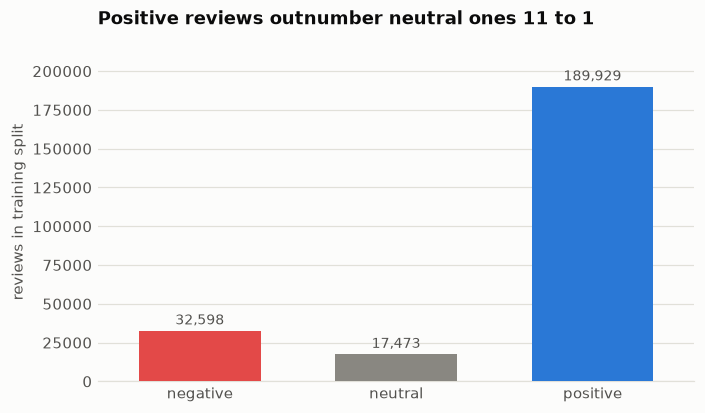

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.bar(CLASS_ORDER, counts.values, color=colors_for(CLASS_ORDER),
              width=0.62, zorder=3)
label_bars(ax, bars, counts.values, fmt="{:,.0f}")

ax.set_title("Positive reviews outnumber neutral ones 11 to 1")
ax.set_ylabel("reviews in training split")
ax.set_ylim(0, counts.max() * 1.15)
ax.margins(x=0.08)

save_figure(fig, "01_class_distribution")
plt.show()

## 2. Where "neutral" comes from

Neutral is a single star rating (3) squeezed between two-star and four-star
bands. That is the structural reason it is both rare *and* hard: a 3-star review
is often a genuinely mixed opinion rather than a distinct sentiment.

saved -> results/figures/02_rating_distribution.png


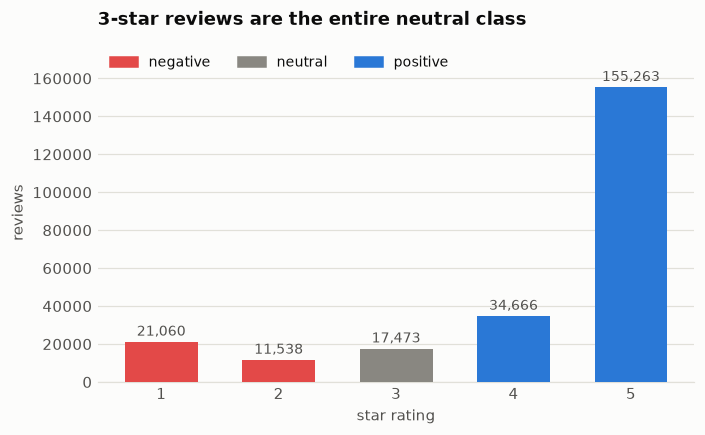

In [5]:
rating_counts = df["rating"].value_counts().sort_index()
rating_colors = [CLASS_COLORS[LABEL_NAMES[0]]] * 2 + \
                [CLASS_COLORS[LABEL_NAMES[1]]] + \
                [CLASS_COLORS[LABEL_NAMES[2]]] * 2

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rating_counts.index.astype(str), rating_counts.values,
              color=rating_colors, width=0.62, zorder=3)
label_bars(ax, bars, rating_counts.values, fmt="{:,.0f}")

ax.set_title("3-star reviews are the entire neutral class")
ax.set_xlabel("star rating")
ax.set_ylabel("reviews")
ax.set_ylim(0, rating_counts.max() * 1.15)

handles = [plt.Rectangle((0, 0), 1, 1, color=CLASS_COLORS[k]) for k in CLASS_ORDER]
ax.legend(handles, CLASS_ORDER, loc="upper left", ncol=3)

save_figure(fig, "02_rating_distribution")
plt.show()

## 3. Review length

This drives a real modelling decision: the `max_len` used to pad/truncate
sequences for the LSTM, Bi-GRU and Bi-LSTM+attention models. Too short and we
cut off the sentiment; too long and we waste compute padding on a 6 GB GPU.

In [6]:
df = df.assign(n_words=df["text_clean"].str.split().str.len())

length_stats = df.groupby("label_name")["n_words"].describe(
    percentiles=[0.5, 0.75, 0.9, 0.95]
).reindex(CLASS_ORDER)
length_stats[["count", "mean", "50%", "75%", "90%", "95%", "max"]].round(1)

,count,mean,50%,75%,90%,95%,max
label_name,,,,,,,
negative,32598.0,73.7,45.0,88.0,158.0,230.0,5534.0
neutral,17473.0,88.4,52.0,104.0,197.0,291.4,2383.0
positive,189929.0,62.0,33.0,71.0,139.0,211.0,5309.0


In [7]:
for p in (0.80, 0.90, 0.95, 0.99):
    print(f"{p:.0%} of reviews are <= {df['n_words'].quantile(p):>6.0f} words")
print(f"\nlongest review: {df['n_words'].max():,} words")

80% of reviews are <=     90 words
90% of reviews are <=    146 words
95% of reviews are <=    220 words
99% of reviews are <=    466 words

longest review: 5,534 words


saved -> results/figures/03_review_length.png


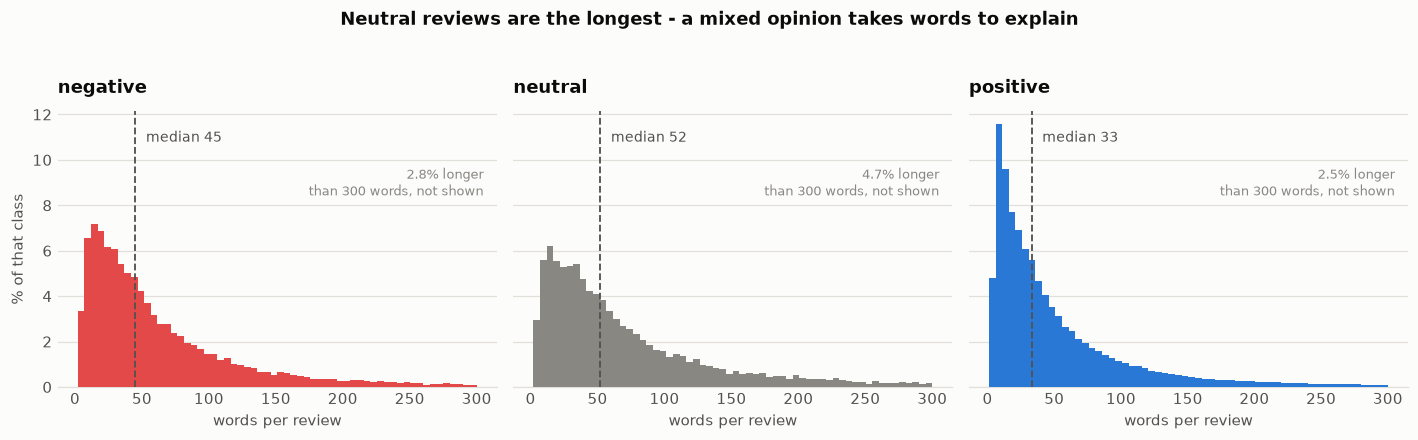

In [8]:
CLIP = 300  # the tail is long but very thin, so the x-axis stops here

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, cls in zip(axes, CLASS_ORDER):
    raw = df.loc[df["label_name"] == cls, "n_words"]
    # Drop the >CLIP tail rather than clipping it: clipping piles every long
    # review into the final bin and draws a spike that looks like real mass.
    vals = raw[raw <= CLIP]
    over = 100 * (len(raw) - len(vals)) / len(raw)
    ax.hist(vals, bins=60, color=CLASS_COLORS[cls], zorder=3,
            weights=np.ones(len(vals)) / len(raw) * 100)
    med = raw.median()
    ax.axvline(med, color=INK_SECONDARY, linestyle="--", linewidth=1.2, zorder=4)
    ax.text(med + 8, 10.8, f"median {med:.0f}", fontsize=9, color=INK_SECONDARY)
    ax.text(0.97, 0.80, f"{over:.1f}% longer\nthan {CLIP} words, not shown",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=8.5, color=INK_MUTED)
    ax.set_title(cls)
    ax.set_xlabel("words per review")
axes[0].set_ylabel("% of that class")

fig.suptitle("Neutral reviews are the longest - a mixed opinion takes words to explain",
             x=0.5, y=1.04, fontsize=12, fontweight="semibold")
fig.tight_layout()
save_figure(fig, "03_review_length")
plt.show()

## 4. Which words distinguish each class?

Raw frequency is useless here - "the", "it" and "phone" dominate every class.
Instead we score each word by how much *more likely* it is in one class than in
the others (a smoothed log-odds ratio). That surfaces genuinely discriminative
vocabulary.

In [9]:
from sklearn.feature_extraction.text import CountVectorizer

vec = CountVectorizer(stop_words="english", min_df=50, max_features=30_000)
X = vec.fit_transform(df["text_clean"])
vocab = np.array(vec.get_feature_names_out())
print(f"{X.shape[0]:,} documents x {X.shape[1]:,} terms")

totals = np.asarray(X.sum(axis=0)).ravel()

distinctive = {}
for cls in CLASS_ORDER:
    mask = (df["label_name"] == cls).values
    in_cls = np.asarray(X[mask].sum(axis=0)).ravel()
    out_cls = totals - in_cls
    # Smoothed probabilities, then log-odds of "inside class" vs "outside".
    p_in = (in_cls + 1) / (in_cls.sum() + len(vocab))
    p_out = (out_cls + 1) / (out_cls.sum() + len(vocab))
    score = np.log(p_in / p_out)
    # Require reasonable support so rare words do not dominate.
    score[in_cls < 30] = -np.inf
    top = np.argsort(score)[::-1][:12]
    distinctive[cls] = pd.Series(score[top], index=vocab[top])

pd.DataFrame({k: v.index for k, v in distinctive.items()})

240,000 documents x 7,217 terms


,negative,neutral,positive
0,scam,feelings,bless
1,waste,meh,lifesaver
2,garbage,alright,perfecto
3,junk,eh,excelente
4,worthless,ok,lightroom
5,paperweight,okay,luv
6,trash,mediocre,awsome
7,doa,blah,rewards
8,pos,execution,godsend
9,refund,delayed,peasy


saved -> results/figures/04_top_words_per_class.png


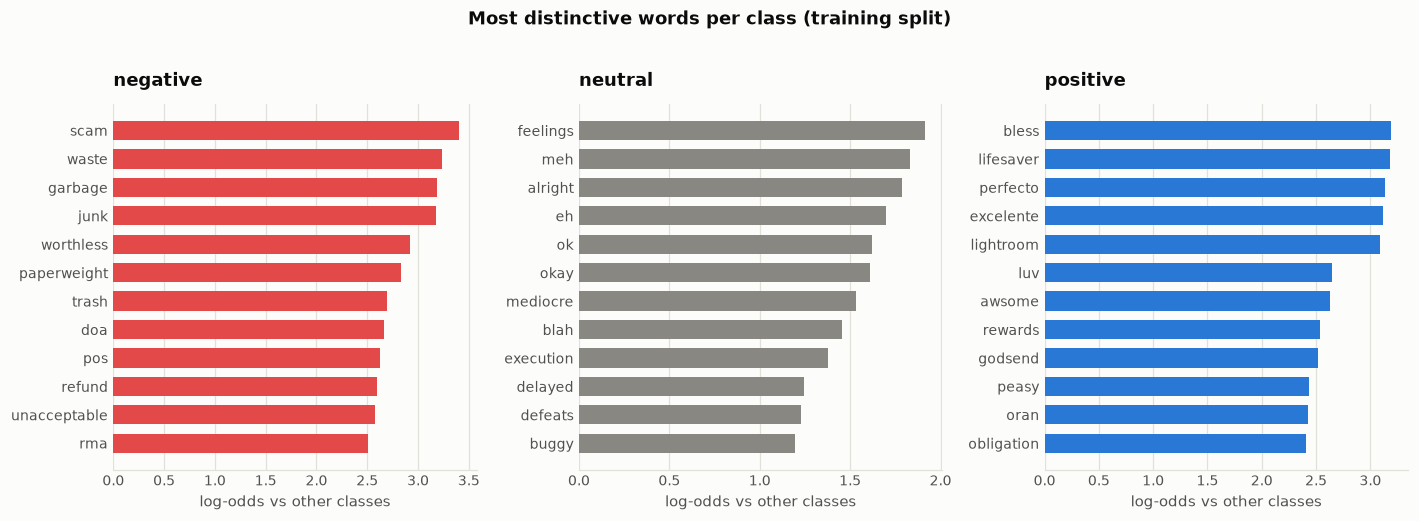

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
for ax, cls in zip(axes, CLASS_ORDER):
    s = distinctive[cls].iloc[::-1]
    ax.barh(s.index, s.values, color=CLASS_COLORS[cls], height=0.68, zorder=3)
    ax.set_title(cls)
    ax.set_xlabel("log-odds vs other classes")
    ax.grid(axis="x"); ax.grid(axis="y", visible=False)
    ax.tick_params(labelsize=9)

fig.suptitle("Most distinctive words per class (training split)",
             x=0.5, y=1.02, fontsize=12, fontweight="semibold")
fig.tight_layout()
save_figure(fig, "04_top_words_per_class")
plt.show()

## 5. Sample reviews

Numbers only go so far. Reading actual reviews - especially neutral ones -
explains in advance why the models will struggle with that class.

In [11]:
rng = np.random.default_rng(42)
for cls in CLASS_ORDER:
    subset = df[df["label_name"] == cls]
    picks = rng.choice(len(subset), size=3, replace=False)
    print("=" * 100)
    print(f"{cls.upper()}")
    print("=" * 100)
    for i in picks:
        row = subset.iloc[i]
        text = row["text"][:300] + ("..." if len(row["text"]) > 300 else "")
        print(f"  [{row['rating']} stars] {text}\n")

NEGATIVE
  [1 stars] One Star. The product did not work when we received but the packaging was OK

  [1 stars] ordered the travel charger and two batteries. the charger .... ordered the travel charger and two batteries .the charger was defective never charged the batteries. currently trying to find website to return it DO NOT BUY

  [1 stars] Very misleading!. Very misleading verbiage...claims to include "Charging Cable Adapter" but DOES NOT! Only includes a plastic holder for an adapter.

NEUTRAL
  [3 stars] I was in love with the bag because it looks just as nice .... I was in love with the bag because it looks just as nice in person. However, it is a lot smaller than I expected and the zipper is already bent after minimal use.

  [3 stars] Okay hardware with very bad software.. I ended up using this colorimeter to profile and calibrate my monitor. Out of the box I was not very happy with the quality of the product. You end up getting pretty much zero instruction and no manual. I had

## Takeaways that shape the modelling

| Finding | Consequence |
|---|---|
| 79% of reviews are positive; neutral is ~7% | Accuracy is meaningless - report macro-F1. Use class weights in the loss. |
| Neutral is exactly the 3-star band | It sits *between* the other two classes semantically, so it will absorb most of the confusion. Expect it to have the lowest per-class F1. |
| Median review is short (33-52 words) but the tail reaches 5,534 words | Pad/truncate to `max_len = 200` (the 94th percentile) rather than the max - padding every sequence to 5,534 would spend almost all the compute on padding tokens. |
| Neutral reviews are the *longest* (median 52 vs 33 for positive) | Length itself carries signal, and it is the minority class that is most expensive to encode - another reason not to truncate too aggressively. |
| Distinctive neutral words are hedges ("okay", "but", "however") | Neutral is expressed through *contrast* within a sentence, which is precisely what an attention layer over a Bi-LSTM should be able to pick up - and what bag-of-words TF-IDF cannot. |